<a href="https://colab.research.google.com/github/itsPius256/Machine-Learning-for-Business-Decisions/blob/main/Individual_Assignment_Machine_learning_25006586_Pius_Kabala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/Hospitality_Wrangling_EDA_Regression.csv')

In [5]:
df.head()

,Booking_ID,Hotel_ID,Country,Brand_Tier,Star_Rating,Room_Type,Nights_Stayed,Booking_Channel,Meals_Included,Payment_Type,...,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
0,2360,H026,SINGAPORE,upscale,4,Double,4,Walk-in,No,Online,...,0.784,415.14,0.83,7.95,0,70.9,458.75,1875.99,43173,2
1,2493,H006,Singapore,economy,1,Double,4,Walk-in,No,Online,...,0.771,104.87,2.95,7.52,0,56.3,103.12,433.34,44423,4
2,172,H033,Thailand,midscale,4,suite,2,Online,Yes,Card,...,0.715,514.49,0.98,8.73,1,56.2,525.62,1123.38,5022,4
3,5659,H018,Malaysia,midscale,3,Single,2,Travel Agent,Yes,Online,...,0.780,265.64,3.68,7.71,0,75.0,263.75,635.46,104455,5
4,5719,H071,Thailand,Midscale,3,Double,2,Online,Yes,Card,...,0.868,212.21,6.81,9.36,0,46.1,234.31,530.34,70545,5


In [6]:
df.describe()

,Booking_ID,Star_Rating,Nights_Stayed,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
count,6630.000000,6630.000000,6630.000000,6368.000000,6630.000000,6630.000000,6630.000000,6630.000000,6562.000000,6447.000000,6630.000000,6489.000000,6630.000000,6490.000000,6599.000000,6630.000000,6630.000000,6630.000000
mean,3250.912217,2.936501,2.496682,37.610867,26.855505,6.244344,0.291855,0.102564,0.729266,288.429727,4.323927,8.306149,0.124133,54.874530,294.417935,803.040131,59830.687179,4.041780
std,1877.481753,1.147861,1.192159,11.641453,19.518938,3.413040,0.454650,0.303412,0.106688,193.514012,4.198526,1.074573,0.329758,11.155025,200.268278,652.926626,34996.892462,0.845549
min,1.000000,1.000000,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.347000,70.000000,0.650000,4.500000,0.000000,15.500000,35.000000,85.660000,136.000000,1.000000
25%,1621.250000,2.000000,2.000000,29.000000,11.000000,3.000000,0.000000,0.000000,0.656000,128.960000,2.800000,7.550000,0.000000,47.300000,131.820000,351.690000,29499.750000,4.000000
50%,3249.500000,3.000000,2.000000,37.000000,25.000000,6.000000,0.000000,0.000000,0.729000,242.820000,3.850000,8.400000,0.000000,54.700000,245.280000,597.150000,59329.500000,4.000000
75%,4876.750000,4.000000,3.000000,46.000000,40.000000,9.000000,1.000000,0.000000,0.803750,391.260000,5.550000,9.180000,0.000000,62.400000,397.945000,1040.710000,90485.000000,5.000000
max,6500.000000,5.000000,7.000000,75.000000,109.000000,12.000000,1.000000,1.000000,0.980000,1884.820000,58.870977,9.800000,1.000000,96.200000,1381.420000,5644.460000,119999.000000,5.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6630 entries, 0 to 6629
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Booking_ID               6630 non-null   int64  
 1   Hotel_ID                 6630 non-null   object 
 2   Country                  6529 non-null   object 
 3   Brand_Tier               6630 non-null   object 
 4   Star_Rating              6630 non-null   int64  
 5   Room_Type                6630 non-null   object 
 6   Nights_Stayed            6630 non-null   int64  
 7   Booking_Channel          6630 non-null   object 
 8   Meals_Included           6472 non-null   object 
 9   Payment_Type             6630 non-null   object 
 10  Customer_Age             6368 non-null   float64
 11  Lead_Time_Days           6630 non-null   int64  
 12  Checkin_Date             6630 non-null   object 
 13  Checkin_Month            6630 non-null   int64  
 14  Is_Weekend              

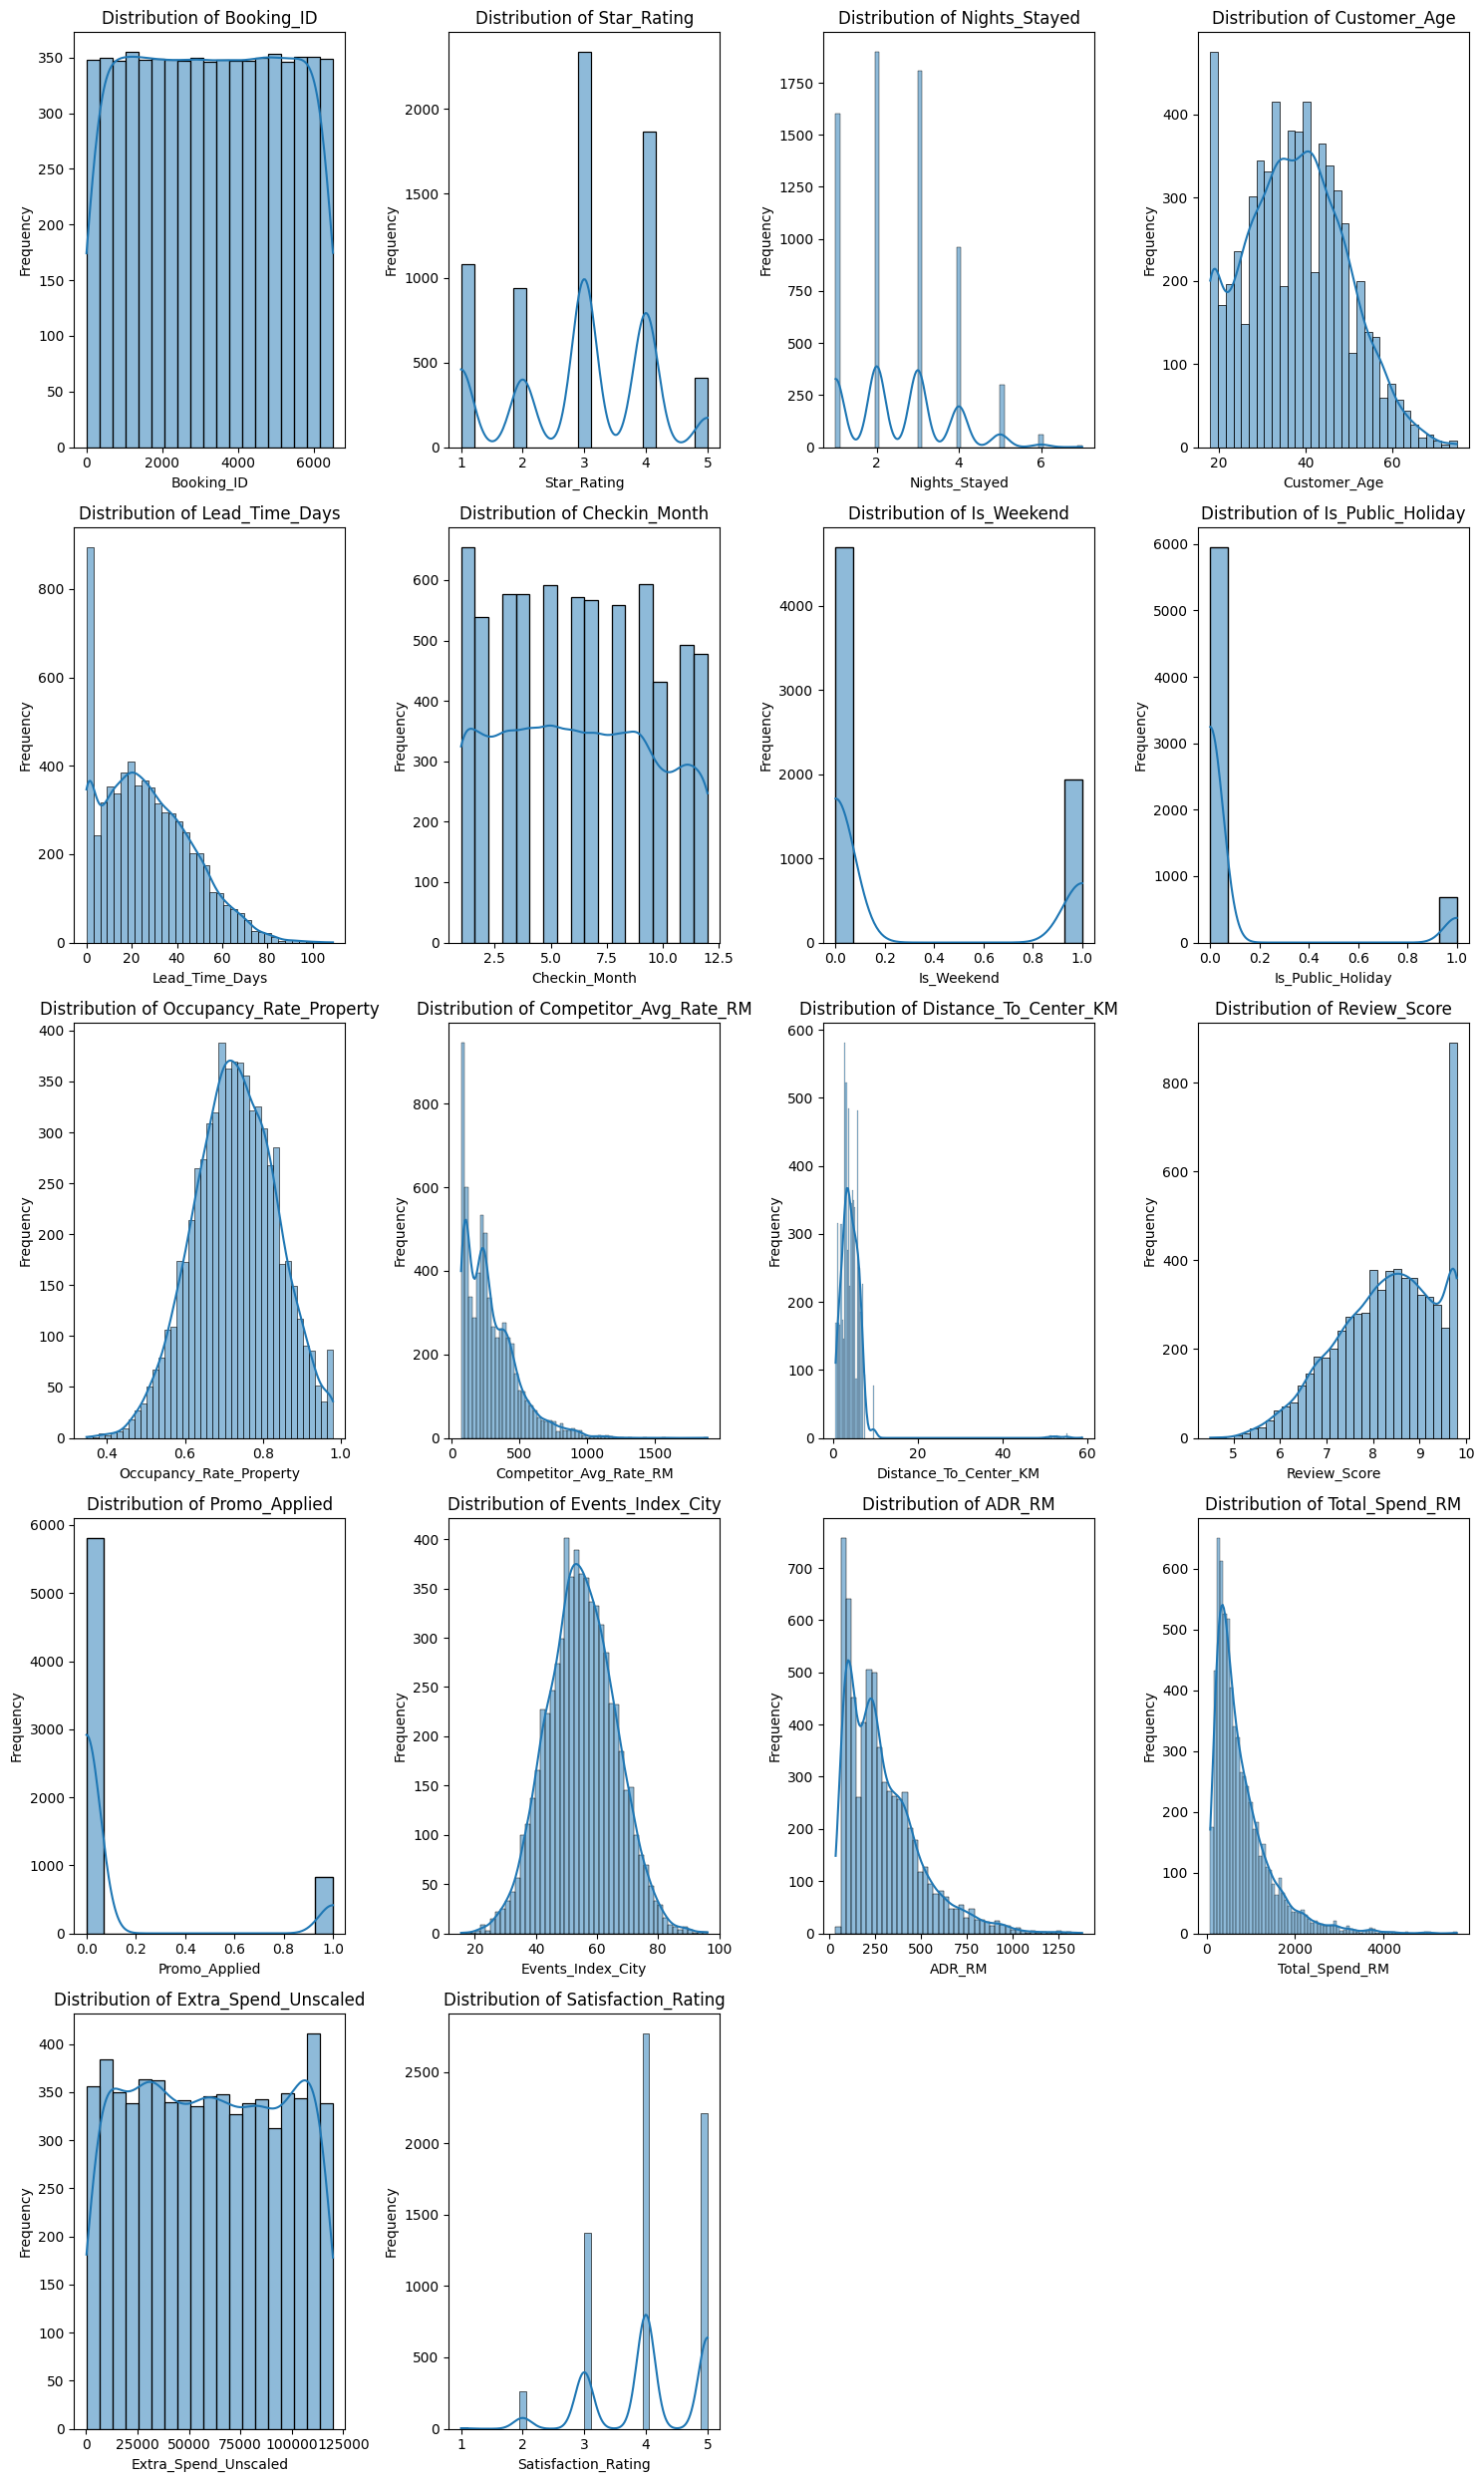

Saved 'distribution_before_handling.png'


<Figure size 640x480 with 0 Axes>

In [8]:
# Visualizing distributions for the features before data handling
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Plot histograms for numerical columns
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
plt.savefig('distribution_before_handling.png')
print("Saved 'distribution_before_handling.png'")

## **Handling duplicates**

In [9]:
num_duplicates = df.duplicated().sum()
print(f"number of duplicates = {num_duplicates}")

number of duplicates = 19


In [10]:
df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean.shape

(6611, 26)

#Handling Missing Values

In [11]:
missing_values_per_column = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing_values_per_column)

total_missing_values = df.isnull().sum().sum()
print(f"\nTotal number of missing values in the dataset: {total_missing_values}")

Missing values per column:
Customer_Age               262
Competitor_Avg_Rate_RM     183
Meals_Included             158
Review_Score               141
Events_Index_City          140
Country                    101
Occupancy_Rate_Property     68
ADR_RM                      31
Hotel_ID                     0
Booking_ID                   0
Payment_Type                 0
Booking_Channel              0
Nights_Stayed                0
Room_Type                    0
Brand_Tier                   0
Star_Rating                  0
Checkin_Month                0
Lead_Time_Days               0
Is_Weekend                   0
Is_Public_Holiday            0
Checkin_Date                 0
Distance_To_Center_KM        0
Promo_Applied                0
Total_Spend_RM               0
Extra_Spend_Unscaled         0
Satisfaction_Rating          0
dtype: int64

Total number of missing values in the dataset: 1084


In [12]:
df_clean.dtypes

,0
Booking_ID,int64
Hotel_ID,object
Country,object
Brand_Tier,object
Star_Rating,int64
Room_Type,object
Nights_Stayed,int64
Booking_Channel,object
Meals_Included,object
Payment_Type,object


In [13]:
df_clean["Customer_Age"] = df_clean["Customer_Age"].replace(np.nan, df_clean["Customer_Age"].mean())
df_clean["Competitor_Avg_Rate_RM"] = df_clean["Competitor_Avg_Rate_RM"].replace(np.nan, df_clean["Competitor_Avg_Rate_RM"].mean())
df_clean["Meals_Included"] = df_clean["Meals_Included"].replace(np.nan, df_clean["Meals_Included"].mode()[0])
df_clean["Review_Score"] = df_clean["Review_Score"].replace(np.nan, df_clean["Review_Score"].mean())
df_clean["Events_Index_City"] = df_clean["Events_Index_City"].replace(np.nan, df_clean["Events_Index_City"].mean())
df_clean["Country"] = df_clean["Country"].replace(np.nan, df_clean["Country"].mode()[0])
df_clean["Occupancy_Rate_Property"] = df_clean["Occupancy_Rate_Property"].replace(np.nan, df_clean["Occupancy_Rate_Property"].mean())
df_clean["ADR_RM"] = df_clean["ADR_RM"].replace(np.nan, df_clean["ADR_RM"].mean())

In [14]:
df_clean.isnull().sum()

,0
Booking_ID,0
Hotel_ID,0
Country,0
Brand_Tier,0
Star_Rating,0
Room_Type,0
Nights_Stayed,0
Booking_Channel,0
Meals_Included,0
Payment_Type,0


In [15]:
#re-check for duplicates
df_clean.duplicated().sum()

np.int64(0)

In [16]:
# Correct Formatting
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].str.strip()

Saved 'outliers_before_scatter.png'


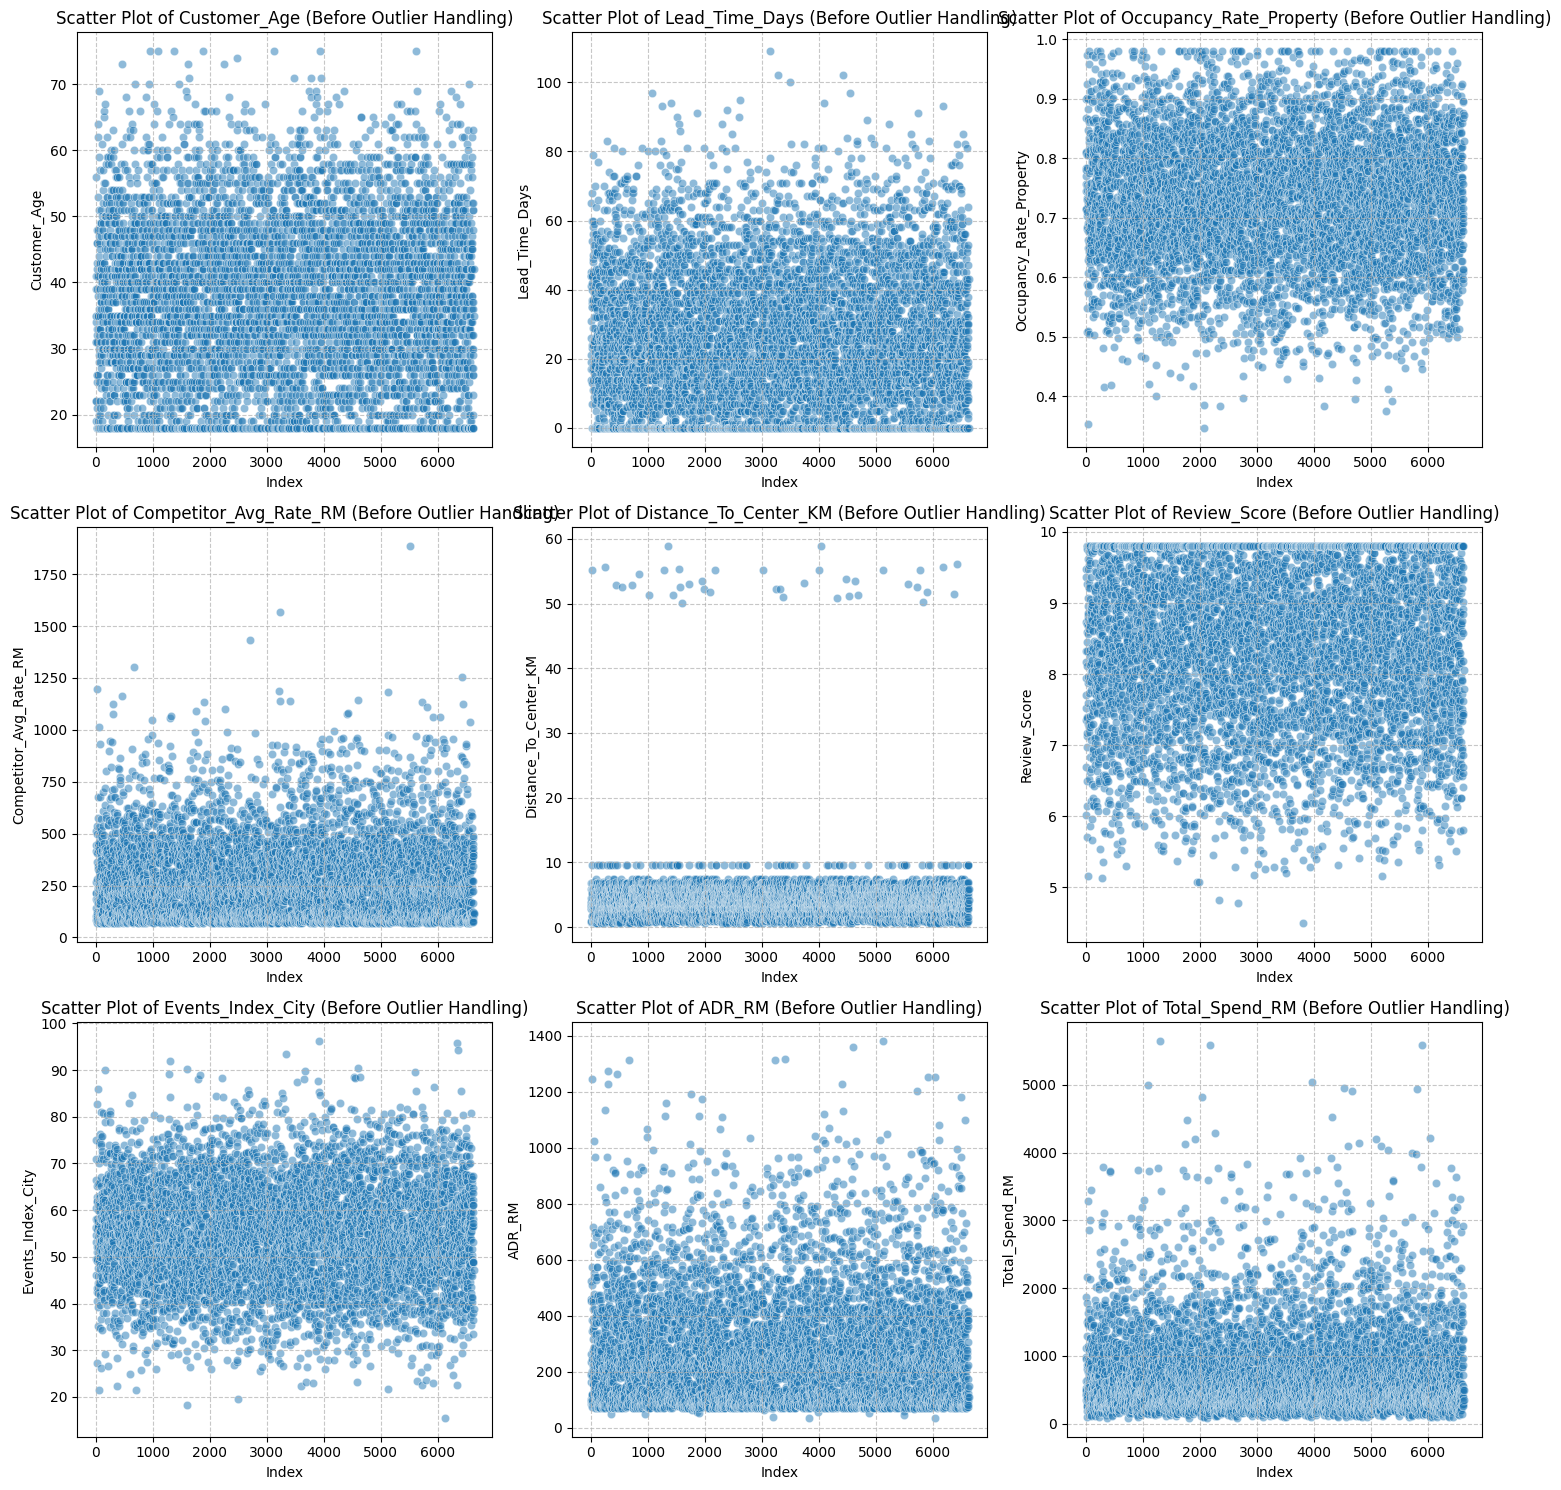

In [17]:
# Visualize Outliers Before Handling
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features_for_viz = [
            'Customer_Age', 'Lead_Time_Days', 'Occupancy_Rate_Property',
            'Competitor_Avg_Rate_RM', 'Distance_To_Center_KM', 'Review_Score',
            'Events_Index_City', 'ADR_RM', 'Total_Spend_RM'
        ]

# Calculate the number of rows and columns for the subplots
n_features = len(numerical_features_for_viz)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(numerical_features_for_viz):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=df.index, y=df[col], alpha=0.5)
    plt.title(f'Scatter Plot of {col} (Before Outlier Handling)')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outliers_before_scatter.png')
print("Saved 'outliers_before_scatter.png'")

Removing Outliers

In [18]:
df_clean.describe()

,Booking_ID,Star_Rating,Nights_Stayed,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
count,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000,6611.000000
mean,3250.134019,2.936772,2.496143,37.611811,26.869157,6.245046,0.291786,0.102254,0.729120,288.485228,4.325203,8.306207,0.124036,54.864457,294.502379,803.258362,59840.170171,4.040387
std,1877.680488,1.148410,1.192047,11.411808,19.520809,3.411492,0.454619,0.303005,0.106138,190.956243,4.203445,1.062916,0.329647,11.032791,199.923033,653.586258,35017.470645,0.845762
min,1.000000,1.000000,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.347000,70.000000,0.650000,4.500000,0.000000,15.500000,35.000000,85.660000,136.000000,1.000000
25%,1621.500000,2.000000,2.000000,29.000000,11.000000,3.000000,0.000000,0.000000,0.657000,131.685000,2.800000,7.570000,0.000000,47.500000,132.010000,351.450000,29496.500000,4.000000
50%,3248.000000,3.000000,2.000000,37.611811,25.000000,6.000000,0.000000,0.000000,0.729120,247.790000,3.850000,8.370000,0.000000,54.864457,246.030000,596.950000,59325.000000,4.000000
75%,4876.500000,4.000000,3.000000,45.000000,40.000000,9.000000,1.000000,0.000000,0.802000,387.130000,5.550000,9.170000,0.000000,62.200000,396.930000,1042.375000,90517.000000,5.000000
max,6500.000000,5.000000,7.000000,75.000000,109.000000,12.000000,1.000000,1.000000,0.980000,1884.820000,58.870977,9.800000,1.000000,96.200000,1381.420000,5644.460000,119999.000000,5.000000


In [19]:
numeric_cols=df_clean.select_dtypes(include=['number']).columns.tolist()
numeric_cols

['Booking_ID',
 'Star_Rating',
 'Nights_Stayed',
 'Customer_Age',
 'Lead_Time_Days',
 'Checkin_Month',
 'Is_Weekend',
 'Is_Public_Holiday',
 'Occupancy_Rate_Property',
 'Competitor_Avg_Rate_RM',
 'Distance_To_Center_KM',
 'Review_Score',
 'Promo_Applied',
 'Events_Index_City',
 'ADR_RM',
 'Total_Spend_RM',
 'Extra_Spend_Unscaled',
 'Satisfaction_Rating']

In [20]:
# Identify outliers using IQR
print("\nIdentifying outliers using IQR:")
outlier_indices = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)].index
    outlier_indices[col] = outliers
    print(f"  {col:>20}: {len(outliers)} outliers identified")

# Combine indices from all columns
all_outlier_indices = [idx for indices in outlier_indices.values() for idx in indices]
all_outlier_indices = list(set(all_outlier_indices))

print(f"\nTotal unique outliers identified across numeric columns: {len(all_outlier_indices)}")



Identifying outliers using IQR:
            Booking_ID: 0 outliers identified
           Star_Rating: 0 outliers identified
         Nights_Stayed: 364 outliers identified
          Customer_Age: 19 outliers identified
        Lead_Time_Days: 26 outliers identified
         Checkin_Month: 0 outliers identified
            Is_Weekend: 0 outliers identified
     Is_Public_Holiday: 676 outliers identified
  Occupancy_Rate_Property: 21 outliers identified
  Competitor_Avg_Rate_RM: 181 outliers identified
  Distance_To_Center_KM: 39 outliers identified
          Review_Score: 8 outliers identified
         Promo_Applied: 820 outliers identified
     Events_Index_City: 52 outliers identified
                ADR_RM: 185 outliers identified
        Total_Spend_RM: 343 outliers identified
  Extra_Spend_Unscaled: 0 outliers identified
   Satisfaction_Rating: 275 outliers identified

Total unique outliers identified across numeric columns: 2280


In [21]:
#checking for outliers
df_clean = df_clean.drop(all_outlier_indices).reset_index(drop=True)

df_clean.shape

(4331, 26)


Visualizing data after outlier handling with scatter plots...
Saved 'outliers_after_scatter.png'


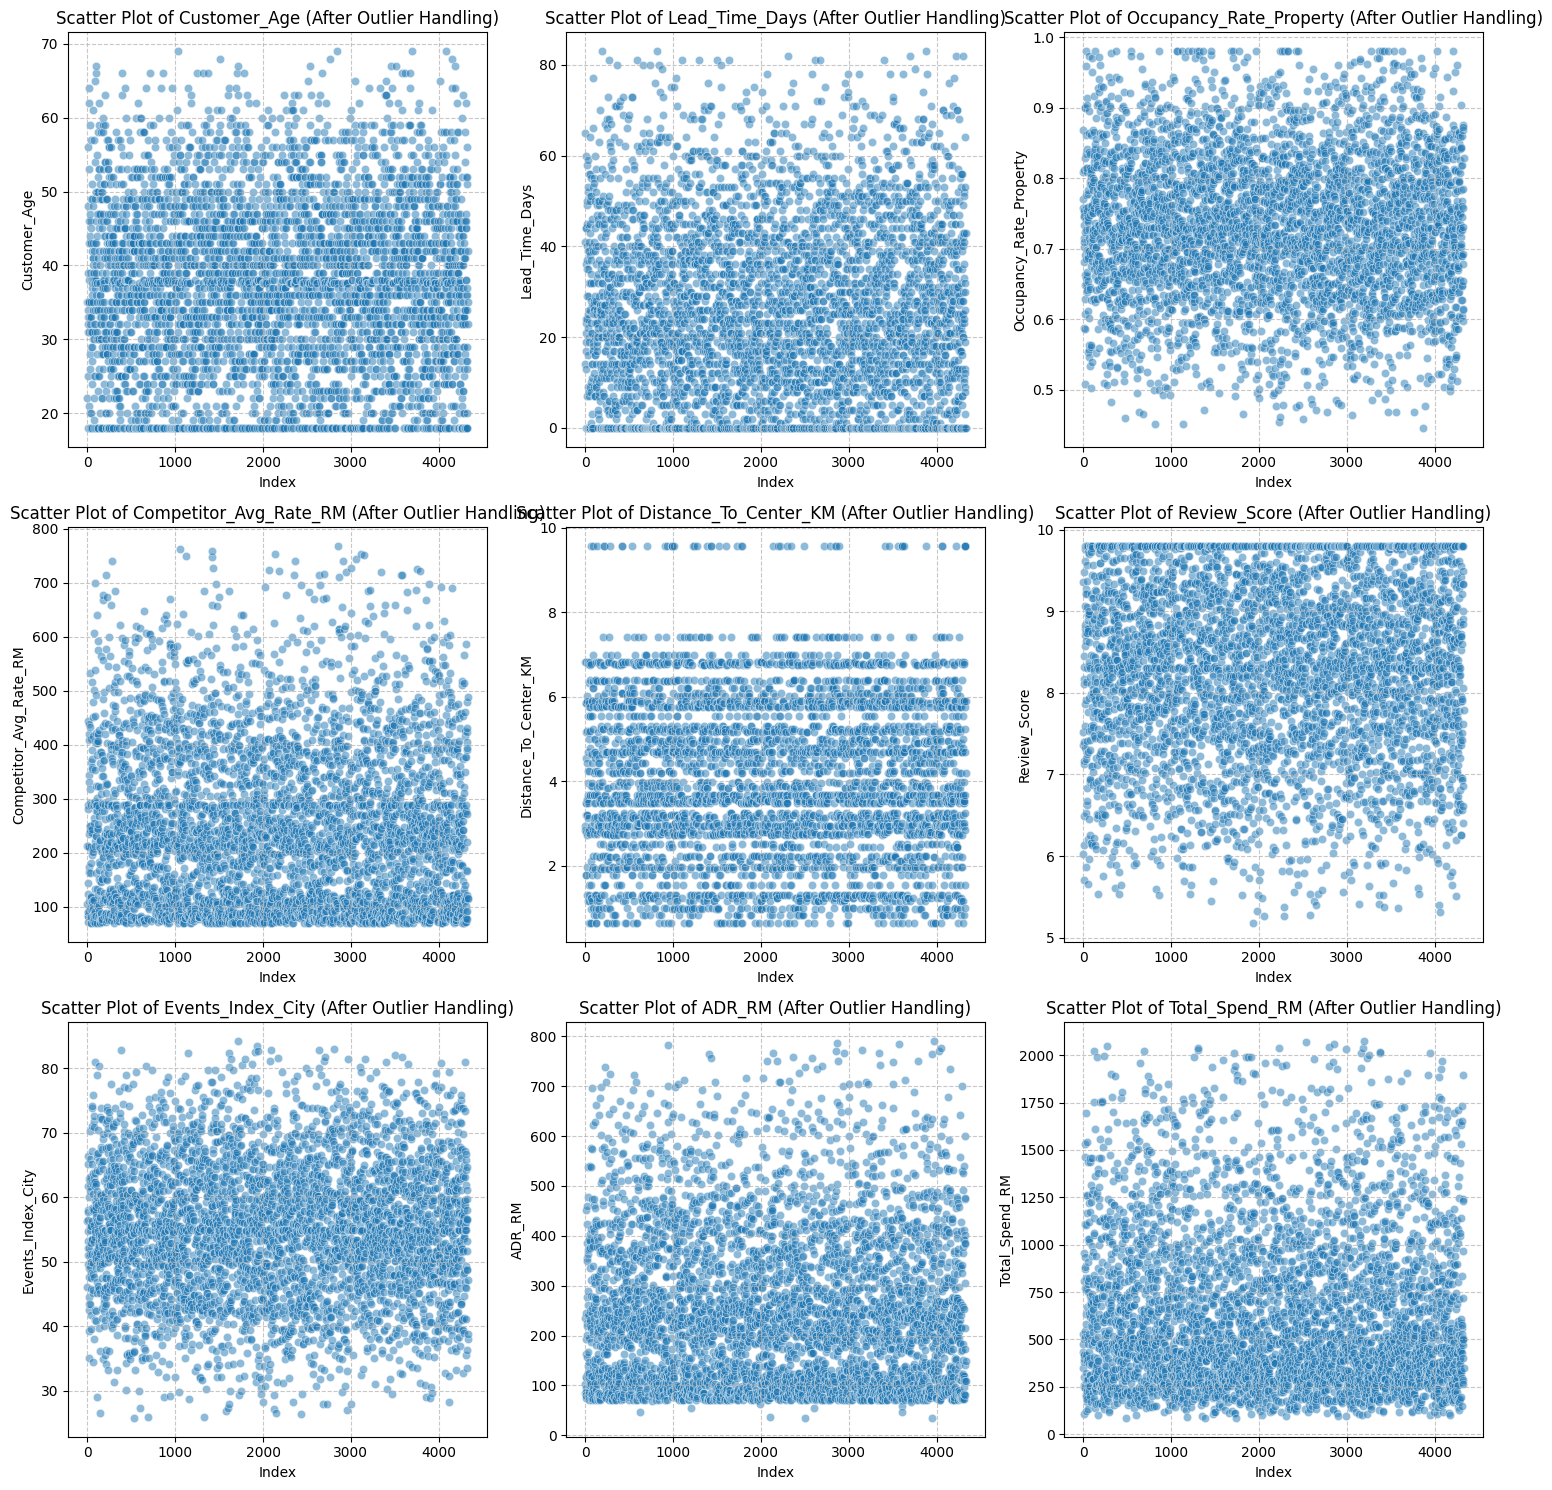

In [22]:
# Visualize Data After Handling Outliers ---
print("\nVisualizing data after outlier handling with scatter plots...")
numerical_features_for_viz = [
            'Customer_Age', 'Lead_Time_Days', 'Occupancy_Rate_Property',
            'Competitor_Avg_Rate_RM', 'Distance_To_Center_KM', 'Review_Score',
            'Events_Index_City', 'ADR_RM', 'Total_Spend_RM'
        ]

n_features = len(numerical_features_for_viz)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(numerical_features_for_viz):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(x=df_clean.index, y=df_clean[col], alpha=0.5)
    plt.title(f'Scatter Plot of {col} (After Outlier Handling)')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('outliers_after_scatter.png')
print("Saved 'outliers_after_scatter.png'")
plt.show()

In [23]:
numeric_features = df_clean.select_dtypes(include=['number'])
numeric_features.head()

,Booking_ID,Star_Rating,Nights_Stayed,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
0,2493,1,4,22.0,41,12,0,0,0.771,104.870000,2.95,7.52,0,56.3,103.12,433.34,44423,4
1,5719,3,2,35.0,65,10,0,0,0.868,212.210000,6.81,9.36,0,46.1,234.31,530.34,70545,5
2,859,1,3,39.0,14,12,1,0,0.757,82.480000,2.84,7.36,0,53.2,83.98,351.21,53100,4
3,1866,1,4,34.0,21,12,0,0,0.809,288.485228,5.85,6.02,0,66.4,94.18,475.33,93786,4
4,6194,3,2,35.0,17,11,0,0,0.745,212.670000,3.48,8.32,0,49.6,193.02,504.28,22595,5


In [24]:
numeric_features.describe()

,Booking_ID,Star_Rating,Nights_Stayed,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,Distance_To_Center_KM,Review_Score,Promo_Applied,Events_Index_City,ADR_RM,Total_Spend_RM,Extra_Spend_Unscaled,Satisfaction_Rating
count,4331.000000,4331.000000,4331.000000,4331.000000,4331.000000,4331.000000,4331.000000,4331.0,4331.000000,4331.000000,4331.000000,4331.000000,4331.0,4331.000000,4331.000000,4331.000000,4331.000000,4331.000000
mean,3232.942277,2.837913,2.300854,37.572218,26.863311,6.178250,0.293235,0.0,0.731940,258.601103,4.017026,8.243668,0.0,54.934087,265.456012,663.279217,59668.793119,4.133918
std,1872.883512,1.095257,1.001499,11.237170,19.069577,3.395636,0.455298,0.0,0.102543,147.765893,1.841246,1.040388,0.0,10.548425,156.610542,423.101724,35047.826343,0.739566
min,1.000000,1.000000,1.000000,18.000000,0.000000,1.000000,0.000000,0.0,0.446000,70.000000,0.650000,5.180000,0.0,25.800000,35.000000,85.660000,136.000000,3.000000
25%,1609.500000,2.000000,1.000000,29.000000,12.000000,3.000000,0.000000,0.0,0.662000,124.890000,2.750000,7.520000,0.0,47.800000,126.290000,328.310000,29373.500000,4.000000
50%,3211.000000,3.000000,2.000000,37.611811,25.000000,6.000000,0.000000,0.0,0.729120,235.300000,3.850000,8.306207,0.0,54.864457,236.930000,537.180000,59059.000000,4.000000
75%,4859.500000,4.000000,3.000000,45.000000,40.000000,9.000000,1.000000,0.0,0.802500,358.300000,5.300000,9.060000,0.0,62.200000,369.905000,901.330000,90563.500000,5.000000
max,6498.000000,5.000000,4.000000,69.000000,83.000000,12.000000,1.000000,0.0,0.980000,767.710000,9.560000,9.800000,0.0,84.200000,790.280000,2074.520000,119999.000000,5.000000


In [25]:
#simple feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Identify numerical columns to scale
cols_to_scale = [
    'Customer_Age', 'Lead_Time_Days', 'Nights_Stayed', 'Star_Rating',
    'Occupancy_Rate_Property', 'Competitor_Avg_Rate_RM', 'Distance_To_Center_KM',
    'Review_Score', 'Events_Index_City', 'Total_Spend_RM', 'Extra_Spend_Unscaled'
]

print("Columns to be scaled:", cols_to_scale)

Columns to be scaled: ['Customer_Age', 'Lead_Time_Days', 'Nights_Stayed', 'Star_Rating', 'Occupancy_Rate_Property', 'Competitor_Avg_Rate_RM', 'Distance_To_Center_KM', 'Review_Score', 'Events_Index_City', 'Total_Spend_RM', 'Extra_Spend_Unscaled']


In [26]:
# Fit the scaler to the data and transform it
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("\nFeature scaling complete. Displaying the first 5 rows with scaled features:")
print(df_clean.head())

# Display descriptive statistics to confirm the scaling
print("\nDescriptive statistics of scaled columns (note the mean is ~0 and std dev is ~1):")
print(df_clean[cols_to_scale].describe())


Feature scaling complete. Displaying the first 5 rows with scaled features:
   Booking_ID Hotel_ID    Country Brand_Tier  Star_Rating Room_Type  \
0        2493     H006  Singapore    economy    -1.678259    Double   
1        5719     H071   Thailand   Midscale     0.148007    Double   
2         859     H005         UK    economy    -1.678259    Single   
3        1866     H074   Malaysia    economy    -1.678259    Double   
4        6194     H066   THAILAND   midscale     0.148007    Single   

   Nights_Stayed Booking_Channel Meals_Included Payment_Type  ...  \
0       1.696799         Walk-in             No       Online  ...   
1      -0.300439          Online            Yes         Card  ...   
2       0.698180          Online            Yes       Online  ...   
3       1.696799    Travel Agent            Yes         Card  ...   
4      -0.300439          Online            Yes         Card  ...   

   Occupancy_Rate_Property  Competitor_Avg_Rate_RM Distance_To_Center_KM  \
0    

Turn Categorical to numerical

In [27]:
categoric_features = df_clean.select_dtypes(include=['object'])
categoric_features.head()

,Hotel_ID,Country,Brand_Tier,Room_Type,Booking_Channel,Meals_Included,Payment_Type,Checkin_Date
0,H006,Singapore,economy,Double,Walk-in,No,Online,2023-12-11
1,H071,Thailand,Midscale,Double,Online,Yes,Card,2023-10-02
2,H005,UK,economy,Single,Online,Yes,Online,2022-12-10
3,H074,Malaysia,economy,Double,Travel Agent,Yes,Card,2024-12-06
4,H066,THAILAND,midscale,Single,Online,Yes,Card,2022-11-07


In [28]:
from sklearn.preprocessing import LabelEncoder
lc_encoding = LabelEncoder()

for col in categoric_features.columns:
    categoric_features[col] = lc_encoding.fit_transform(categoric_features[col])

categoric_features.head()

,Hotel_ID,Country,Brand_Tier,Room_Type,Booking_Channel,Meals_Included,Payment_Type,Checkin_Date
0,5,13,8,1,8,3,5,678
1,70,15,5,1,3,5,2,609
2,4,16,8,4,3,5,5,330
3,73,7,8,1,5,5,2,1026
4,65,14,10,4,3,5,2,297


In [29]:
# Ensure both are DataFrames before concatenating
numeric_features = pd.DataFrame(numeric_features)
categoric_features = pd.DataFrame(categoric_features)

print(f"Type of numeric_features: {type(numeric_features)}")
print(f"Type of categoric_features: {type(categoric_features)}")

df_cleaned = pd.concat([numeric_features, categoric_features], axis=1)
df_cleaned.head()

Type of numeric_features: <class 'pandas.core.frame.DataFrame'>
Type of categoric_features: <class 'pandas.core.frame.DataFrame'>


,Booking_ID,Star_Rating,Nights_Stayed,Customer_Age,Lead_Time_Days,Checkin_Month,Is_Weekend,Is_Public_Holiday,Occupancy_Rate_Property,Competitor_Avg_Rate_RM,...,Extra_Spend_Unscaled,Satisfaction_Rating,Hotel_ID,Country,Brand_Tier,Room_Type,Booking_Channel,Meals_Included,Payment_Type,Checkin_Date
0,2493,1,4,22.0,41,12,0,0,0.771,104.870000,...,44423,4,5,13,8,1,8,3,5,678
1,5719,3,2,35.0,65,10,0,0,0.868,212.210000,...,70545,5,70,15,5,1,3,5,2,609
2,859,1,3,39.0,14,12,1,0,0.757,82.480000,...,53100,4,4,16,8,4,3,5,5,330
3,1866,1,4,34.0,21,12,0,0,0.809,288.485228,...,93786,4,73,7,8,1,5,5,2,1026
4,6194,3,2,35.0,17,11,0,0,0.745,212.670000,...,22595,5,65,14,10,4,3,5,2,297


In [30]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4331 entries, 0 to 4330
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Booking_ID               4331 non-null   int64  
 1   Star_Rating              4331 non-null   int64  
 2   Nights_Stayed            4331 non-null   int64  
 3   Customer_Age             4331 non-null   float64
 4   Lead_Time_Days           4331 non-null   int64  
 5   Checkin_Month            4331 non-null   int64  
 6   Is_Weekend               4331 non-null   int64  
 7   Is_Public_Holiday        4331 non-null   int64  
 8   Occupancy_Rate_Property  4331 non-null   float64
 9   Competitor_Avg_Rate_RM   4331 non-null   float64
 10  Distance_To_Center_KM    4331 non-null   float64
 11  Review_Score             4331 non-null   float64
 12  Promo_Applied            4331 non-null   int64  
 13  Events_Index_City        4331 non-null   float64
 14  ADR_RM                  

In [31]:
df_cleaned.to_csv('customer_cleaned.csv',index=False)

In [32]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4331 entries, 0 to 4330
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Booking_ID               4331 non-null   int64  
 1   Star_Rating              4331 non-null   int64  
 2   Nights_Stayed            4331 non-null   int64  
 3   Customer_Age             4331 non-null   float64
 4   Lead_Time_Days           4331 non-null   int64  
 5   Checkin_Month            4331 non-null   int64  
 6   Is_Weekend               4331 non-null   int64  
 7   Is_Public_Holiday        4331 non-null   int64  
 8   Occupancy_Rate_Property  4331 non-null   float64
 9   Competitor_Avg_Rate_RM   4331 non-null   float64
 10  Distance_To_Center_KM    4331 non-null   float64
 11  Review_Score             4331 non-null   float64
 12  Promo_Applied            4331 non-null   int64  
 13  Events_Index_City        4331 non-null   float64
 14  ADR_RM                  

In [33]:
df_numeric = df.select_dtypes(include=('number'))
df_numeric.head()
df_numeric.dtypes

,0
Booking_ID,int64
Star_Rating,int64
Nights_Stayed,int64
Customer_Age,float64
Lead_Time_Days,int64
Checkin_Month,int64
Is_Weekend,int64
Is_Public_Holiday,int64
Occupancy_Rate_Property,float64
Competitor_Avg_Rate_RM,float64


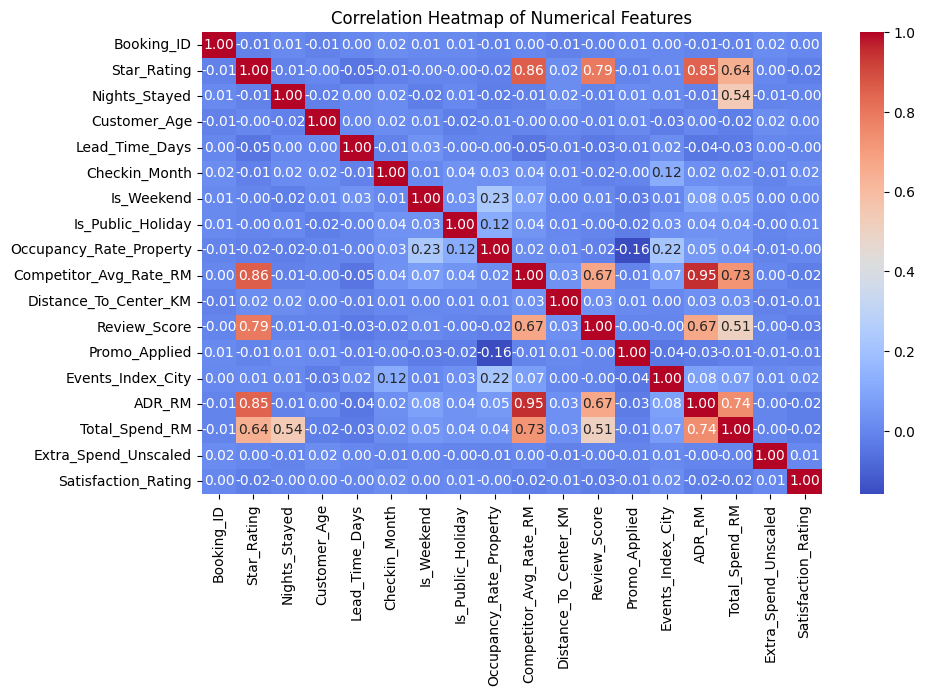

Saved 'correlation_heatmap.png'


<Figure size 640x480 with 0 Axes>

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = df.select_dtypes(include=('number'))

df_numeric.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()
plt.savefig('correlation_heatmap.png')
print("Saved 'correlation_heatmap.png'")

In [35]:
# Feature 1: Create 'Total_Guests' from 'Room_Type'
guest_map = {'Single': 1, 'Double': 2, 'Suite': 3}
df['Total_Guests'] = df['Room_Type'].map(guest_map)
print("Created new feature: 'Total_Guests'")

Created new feature: 'Total_Guests'


In [36]:
# Feature 2: Create 'Booking_Season' from 'Checkin_Month'
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'
df['Booking_Season'] = df['Checkin_Month'].apply(get_season)
print("Created new feature: 'Booking_Season'")

Created new feature: 'Booking_Season'


In [37]:
# One-Hot Encoding
# Identify categorical columns to encode
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.append('Booking_Season')

print("Categorical features to be encoded:", categorical_features)

Categorical features to be encoded: ['Hotel_ID', 'Country', 'Brand_Tier', 'Room_Type', 'Booking_Channel', 'Meals_Included', 'Payment_Type', 'Checkin_Date', 'Booking_Season', 'Booking_Season']


In [38]:
# Apply one-hot encoding using pandas get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
print("One-hot encoding complete.")

One-hot encoding complete.


In [39]:
# Display the new shape and some of the new columns
print(f"Shape of the dataframe after encoding: {df_encoded.shape}")
print("Example of new columns created:", df_encoded.columns[-5:].tolist())

Shape of the dataframe after encoding: (6630, 1614)
Example of new columns created: ['Booking_Season_Summer', 'Booking_Season_Winter', 'Booking_Season_Spring', 'Booking_Season_Summer', 'Booking_Season_Winter']


Saved 'correlation_heatmap.png'


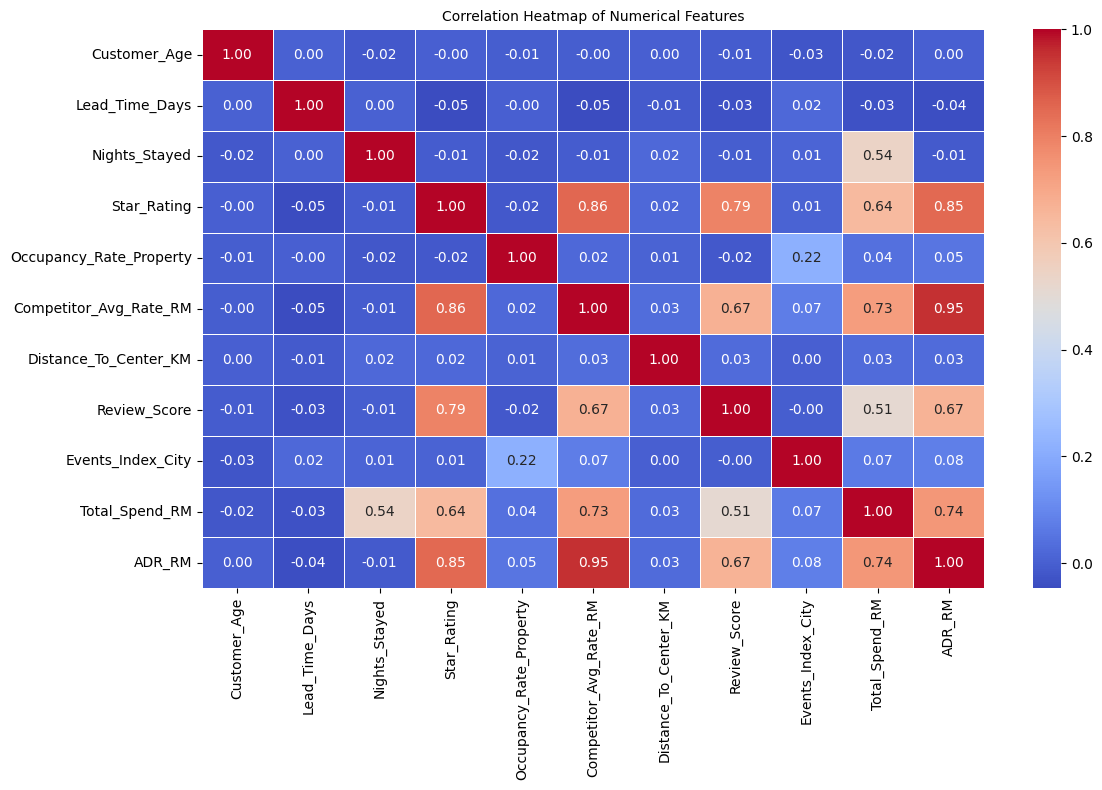

In [40]:
# EDA Visualization
plt.figure(figsize=(12, 8))
numerical_cols_for_corr = [
  'Customer_Age', 'Lead_Time_Days', 'Nights_Stayed', 'Star_Rating',
  'Occupancy_Rate_Property', 'Competitor_Avg_Rate_RM', 'Distance_To_Center_KM',
  'Review_Score', 'Events_Index_City', 'Total_Spend_RM', 'ADR_RM'
]
correlation_matrix = df[numerical_cols_for_corr].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
print("Saved 'correlation_heatmap.png'")

Saved 'adr_distribution.png'


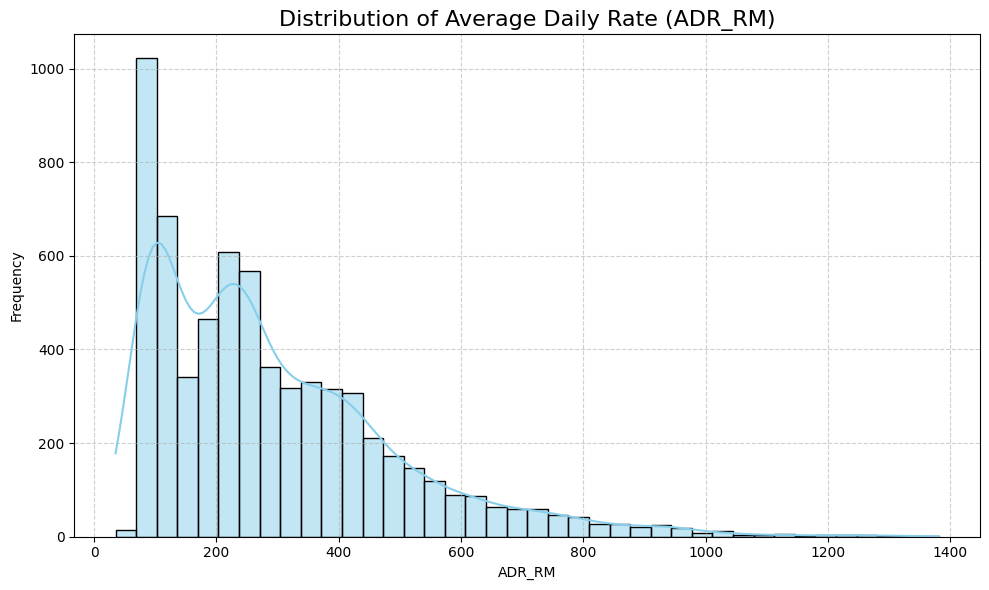

In [41]:
 #  Distribution of the Target Variable (ADR_RM)
plt.figure(figsize=(10, 6))
sns.histplot(df['ADR_RM'], kde=True, bins=40, color='skyblue')
plt.title('Distribution of Average Daily Rate (ADR_RM)', fontsize=16)
plt.xlabel('ADR_RM')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('adr_distribution.png')

print("Saved 'adr_distribution.png'")

/tmp/ipython-input-2585749093.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Brand_Tier', y='ADR_RM', data=df, ax=axes[0], palette='plasma', order=['economy', 'midscale', 'upscale'])
/tmp/ipython-input-2585749093.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Booking_Season', y='ADR_RM', data=df, ax=axes[1], palette='viridis', order=['Winter', 'Spring', 'Summer', 'Autumn'])


Saved 'categorical_plots.png'


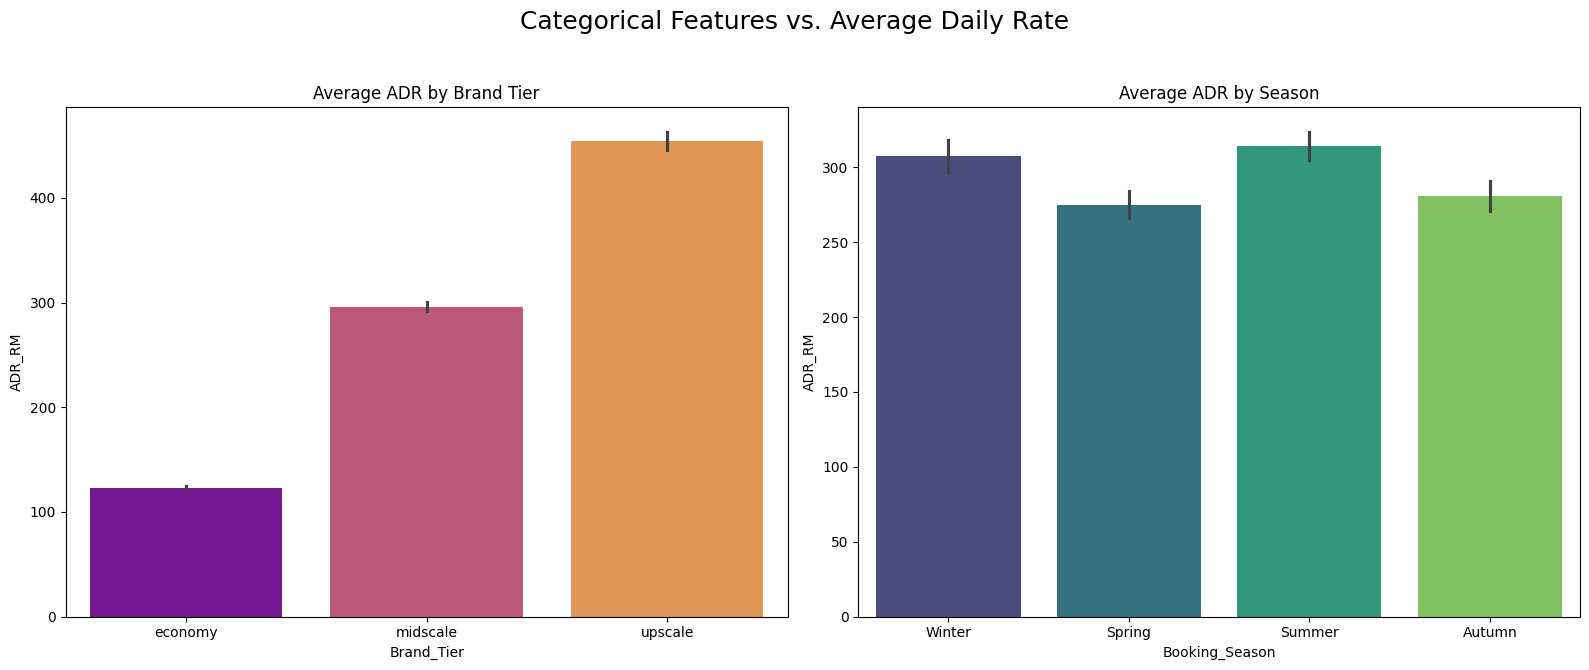

In [42]:
# Bar Plots for Key Categorical Features vs. ADR_RM
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'
df['Booking_Season'] = df['Checkin_Month'].apply(get_season)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Categorical Features vs. Average Daily Rate', fontsize=18)

sns.barplot(x='Brand_Tier', y='ADR_RM', data=df, ax=axes[0], palette='plasma', order=['economy', 'midscale', 'upscale'])
axes[0].set_title('Average ADR by Brand Tier')

sns.barplot(x='Booking_Season', y='ADR_RM', data=df, ax=axes[1], palette='viridis', order=['Winter', 'Spring', 'Summer', 'Autumn'])
axes[1].set_title('Average ADR by Season')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('categorical_plots.png')
print("Saved 'categorical_plots.png'")

In [43]:
# Define Features (X) and Target (y)
y = df_cleaned['ADR_RM']
# Drop the target variable and non-predictive identifiers
X = df_cleaned.drop(columns=['ADR_RM', 'Booking_ID', 'Hotel_ID', 'Checkin_Date'])

# One-Hot Encode Categorical Features
categorical_features_X = X.select_dtypes(include=['object']).columns.tolist()

X = pd.get_dummies(X, columns=categorical_features_X, drop_first=True)

In [44]:
# Save Preprocessing Artifacts
import joblib

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the final feature column list after encoding
trained_feature_columns = X.columns
joblib.dump(trained_feature_columns, 'feature_columns.pkl')

print(" Saved scaler.pkl and feature_columns.pkl for deployment.")


 Saved scaler.pkl and feature_columns.pkl for deployment.


In [45]:
# Split Data into Training and Testing Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (3031, 22)
Shape of X_test: (1300, 22)
Shape of y_train: (3031,)
Shape of y_test: (1300,)


In [46]:
print(pd.isnull(y_train).sum())

0


**Model Training and Evaluation**

In [47]:
# Using decision Tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
model_DT = DecisionTreeRegressor(random_state=42)

#To train the model
model_DT.fit(X_train, y_train)

#To predict
y_pred_DT = model_DT.predict(X_test)

#To evaluate
mae_DT = mean_absolute_error(y_test, y_pred_DT)
mse_DT = mean_squared_error(y_test, y_pred_DT)
rmse_DT = np.sqrt(mean_squared_error(y_test, y_pred_DT))
r2_DT = r2_score(y_test, y_pred_DT)*100

print(f"Mean Squared Error (MSE): {mse_DT:.2f}")
print(f"Mean Absolute Error (MAE): {mae_DT:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_DT:.2f}")
print(f"R-squared (R2): {r2_DT:.2f}")

Mean Squared Error (MSE): 1810.80
Mean Absolute Error (MAE): 24.26
Root Mean Squared Error (RMSE): 42.55
R-squared (R2): 92.75


In [48]:
# Using Random Forest
from sklearn.ensemble import RandomForestRegressor
model_RF = RandomForestRegressor(random_state=42)

#To train the model
model_RF.fit(X_train, y_train)

#To predict
y_pred_RF = model_RF.predict(X_test)

#To evaluate
mae_RF = mean_absolute_error(y_test, y_pred_RF)
mse_RF = mean_squared_error(y_test, y_pred_RF)
rmse_RF = np.sqrt(mean_squared_error(y_test, y_pred_RF))
r2_RF = r2_score(y_test, y_pred_RF)*100

print(f"Mean Squared Error (MSE): {mse_RF:.2f}")
print(f"Mean Absolute Error (MAE): {mae_RF:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_RF:.2f}")

Mean Squared Error (MSE): 1352.45
Mean Absolute Error (MAE): 19.00
Root Mean Squared Error (RMSE): 36.78


In [49]:
# Using Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
model_GB = GradientBoostingRegressor(random_state=42)

#To train the model
model_GB.fit(X_train, y_train)

#To predict
y_pred_GB = model_GB.predict(X_test)

#To evaluate
mae_GB = mean_absolute_error(y_test, y_pred_GB)
mse_GB = mean_squared_error(y_test, y_pred_GB)
rmse_GB = np.sqrt(mean_squared_error(y_test, y_pred_GB))
r2_GB = r2_score(y_test, y_pred_GB)*100

print(f"Mean Squared Error (MSE): {mse_GB:.2f}")
print(f"Mean Absolute Error (MAE): {mae_GB:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_GB:.2f}")
print(f"R-squared (R2): {r2_GB:.2f}")

Mean Squared Error (MSE): 838.77
Mean Absolute Error (MAE): 17.28
Root Mean Squared Error (RMSE): 28.96
R-squared (R2): 96.64


In [50]:
# Using Logistics regression
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()

#To train the model
model_LR.fit(X_train, y_train)

#To predict
y_pred_LR = model_LR.predict(X_test)

#To evaluate
mae_LR = mean_absolute_error(y_test, y_pred_LR)
mse_LR = mean_squared_error(y_test, y_pred_LR)
rmse_LR= np.sqrt(mean_squared_error(y_test, y_pred_LR))
r2_LR = r2_score(y_test, y_pred_LR)*100

print(f"Mean Squared Error (MSE): {mse_LR:.2f}")
print(f"Mean Absolute Error (MAE): {mae_LR:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_LR:.2f}")
print(f"Mean Absolute Error (MAE): {mae_LR:.2f}")

Mean Squared Error (MSE): 1888.73
Mean Absolute Error (MAE): 28.06
Root Mean Squared Error (RMSE): 43.46
Mean Absolute Error (MAE): 28.06


In [51]:
import pandas as pd

# Create a dictionary to store the evaluation metrics for each model
results = {
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'Linear Regression'],
    'MSE': [mse_DT, mse_RF, mse_GB, mse_LR],
    'MAE': [mae_DT, mae_RF, mae_GB, mae_LR],
    'RMSE': [rmse_DT, rmse_RF, rmse_GB, rmse_LR],
    'R-squared': [r2_DT, r2_RF, r2_GB, r2_LR]
}

# Create a pandas DataFrame from the results dictionary
results_df = pd.DataFrame(results)

# Display the results table
display(results_df)

,Model,MSE,MAE,RMSE,R-squared
0,Decision Tree,1810.799060,24.264980,42.553485,92.747113
1,Random Forest,1352.452769,19.004001,36.775709,94.582951
2,Gradient Boosting,838.770376,17.282624,28.961533,96.640430
3,Linear Regression,1888.727975,28.060438,43.459498,92.434980


From the table above Gradient Boosting model performs best shown by the highest R-squared value and the lowest mean Absolute Error and Root Mean Squared Error

/tmp/ipython-input-3816445601.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R-squared', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipython-input-3816445601.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[1], palette='plasma')
/tmp/ipython-input-3816445601.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[2], palette='coolwarm')


Saved 'initial_model_performance.png'


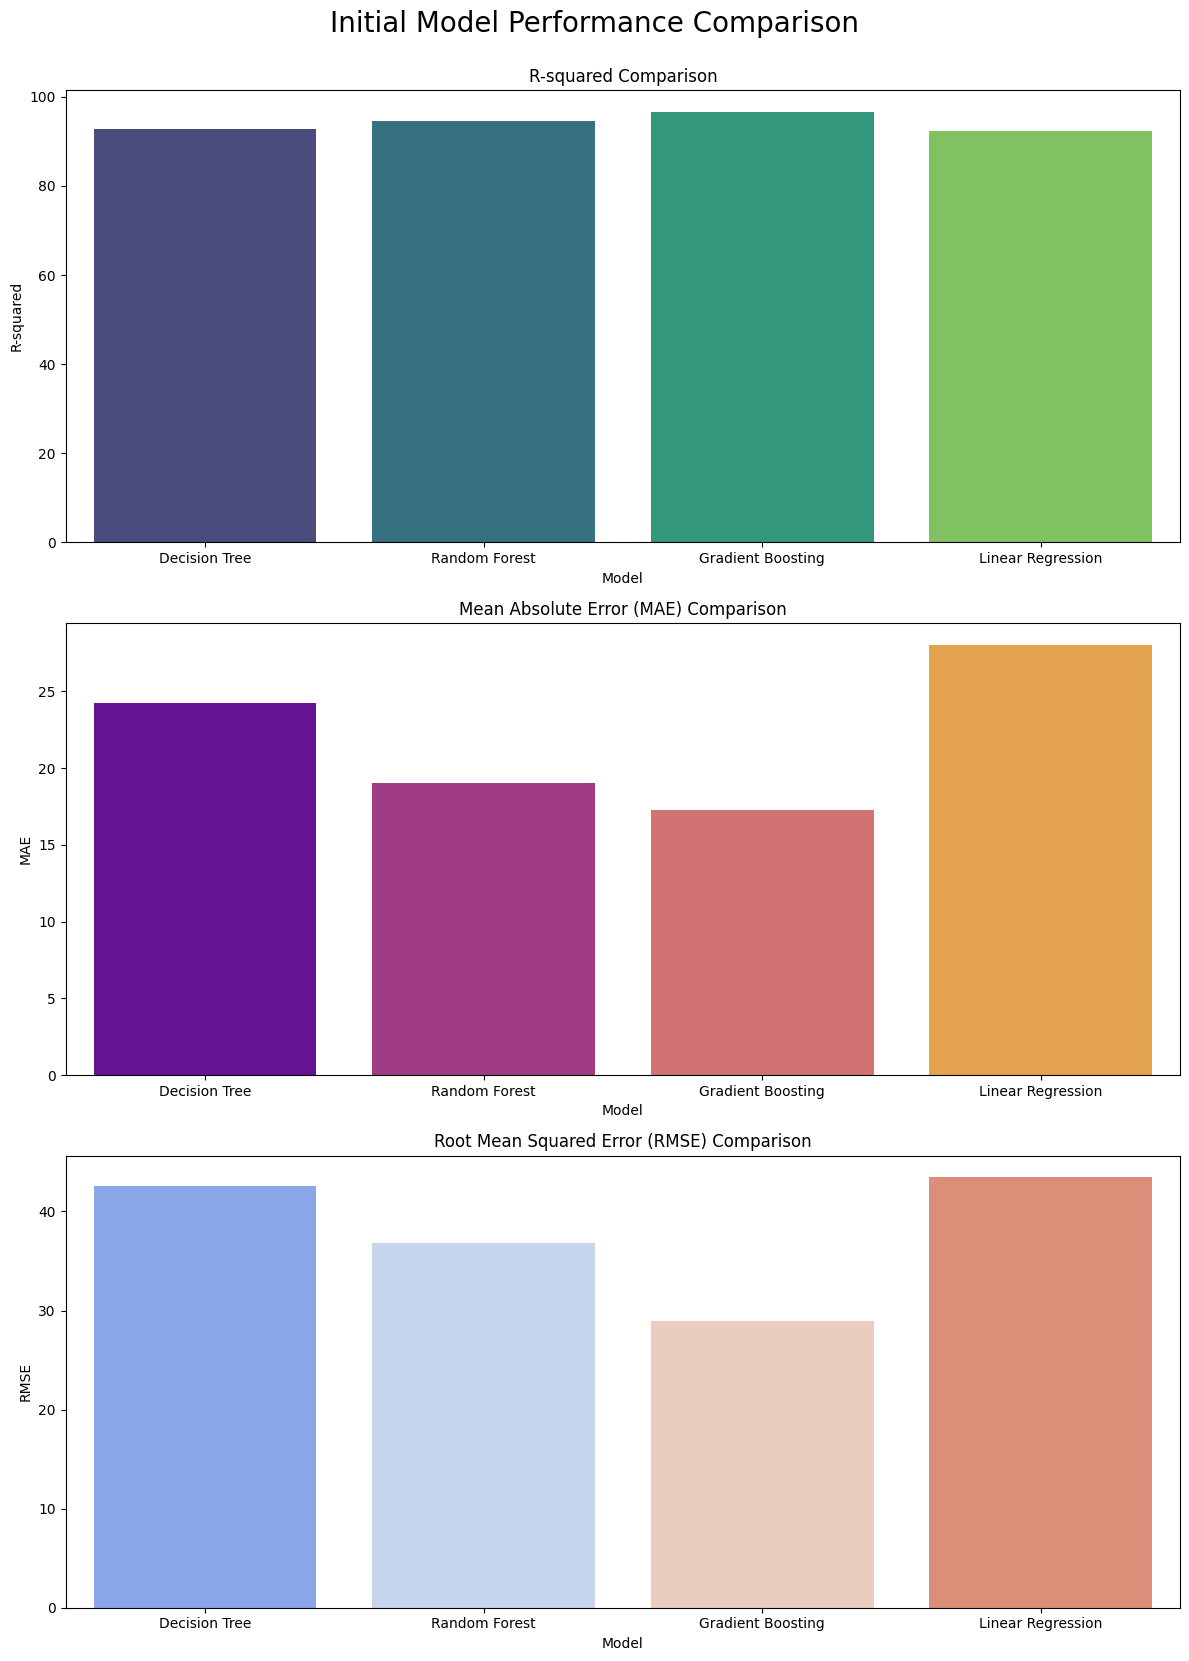

In [52]:
# To visualize the model performance
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Initial Model Performance Comparison', fontsize=20, y=0.95)

# Plot for R-squared
sns.barplot(x='Model', y='R-squared', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R-squared Comparison')
axes[0].set_ylabel('R-squared')

# Plot for Mean Absolute Error (MAE)
sns.barplot(x='Model', y='MAE', data=results_df, ax=axes[1], palette='plasma')
axes[1].set_title('Mean Absolute Error (MAE) Comparison')
axes[1].set_ylabel('MAE')

# Plot for Root Mean Squared Error(RMSE)
sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Root Mean Squared Error (RMSE) Comparison')
axes[2].set_ylabel('RMSE')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('initial_model_performance.png')
print("Saved 'initial_model_performance.png'")
plt.show()

In [53]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100,200],
    'learning_rate' : [0.05,0.1],
    'max_depth': [3,4,5]
}

# Using the baseline Gradient Boosting model as the estimator.
grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                              param_grid=param_grid,
                              cv=3,
                              n_jobs=-1,
                              verbose=2,
                              scoring='neg_mean_squared_error')

print("Grid search initiated...")
grid_search.fit(X_train, y_train)
print("Grid search completed.")

# To get the best model
best_model_gb = grid_search.best_estimator_
print(f"Best Model: {best_model_gb}")

Grid search initiated...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Grid search completed.
Best Model: GradientBoostingRegressor(max_depth=4, n_estimators=200, random_state=42)


In [54]:
# Evaluate the Tuned model
y_pred_gb_tuned = best_model_gb.predict(X_test)

# Calculating new evaluation metrics
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
mse_gb_tuned = mean_squared_error(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)*100

print(f"Mean Squared Error (MSE): {mse_gb_tuned:.2f}")
print(f"Mean Absolute Error (MAE): {mae_gb_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gb_tuned:.2f}")
print(f"R-squared (R2): {r2_gb_tuned:.2f}")

Mean Squared Error (MSE): 734.84
Mean Absolute Error (MAE): 15.13
Root Mean Squared Error (RMSE): 27.11
R-squared (R2): 97.06


In [55]:
# Storing the new results
new_results = {
    'Model': ['Gradient Boosting (Tuned)'],
    'MSE': [mse_gb_tuned],
    'MAE': [mae_gb_tuned],
    'RMSE': [rmse_gb_tuned],
    'R-squared': [r2_gb_tuned]
}

new_results_df = pd.DataFrame(new_results)

In [56]:
# Compare Before and After
original_gb_results = results_df[results_df['Model'] == 'Gradient Boosting']
tuned_gb_results = new_results_df

comparison_df = pd.concat([original_gb_results, tuned_gb_results], ignore_index=True)
print(comparison_df)

                       Model         MSE        MAE       RMSE  R-squared
0          Gradient Boosting  838.770376  17.282624  28.961533   96.64043
1  Gradient Boosting (Tuned)  734.844258  15.134030  27.108011   97.05669


Saved 'gb_performance_comparison.png'


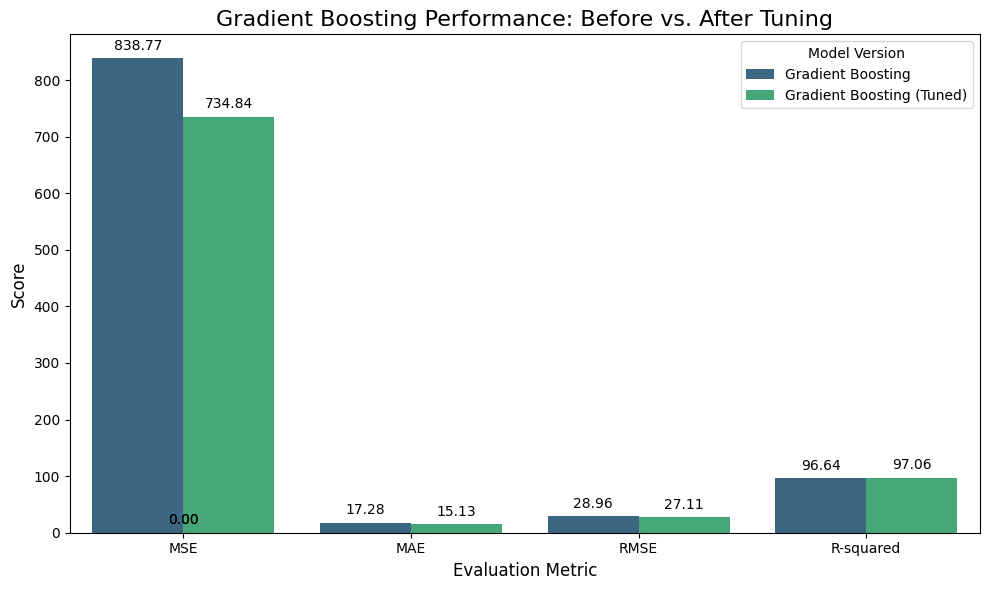

In [57]:
# To visualize the comparason
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Reshape the comparison_df for plotting
comparison_df_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

comparison_df_melted = comparison_df_melted.rename(columns={'Model': 'Model_Version'})

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Metric', y='Score', hue='Model_Version', data = comparison_df_melted, palette='viridis')

# Adding text labels on top of each bar
for p in barplot.patches:
  barplot.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() /2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title('Gradient Boosting Performance: Before vs. After Tuning', fontsize=16)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Model Version')
plt.tight_layout()
plt.savefig('gb_performance_comparison.png')
print("Saved 'gb_performance_comparison.png'")
plt.show()

In [58]:
# saving the gradient Boosting model
import joblib
joblib.dump(best_model_gb, 'gradient_boosting_model.pkl')
print("Model saved successfully as 'gradient_boosting_model.pkl' ")

Model saved successfully as 'gradient_boosting_model.pkl' 


In [ ]:
# Development
import gradio as gr
from sklearn.ensemble import GradientBoostingRegressor
import joblib
import numpy as np

# Load the trained model
model = joblib.load('gradient_boosting_model.pkl')

model_columns = X_train.columns.tolist()
print(model_columns)

In [ ]:
# Defining the prediction function that Gradio will use
def predict_adr(star_rating, brand_tier, room_type, lead_time, is_weekend, dist_center, competitor_rate, nights_stayed):

    # Creating a dictionary from the input
    input_data = {
            'Star_Rating': star_rating,
            'Nights_Stayed': nights_stayed,
            'Lead_Time_Days': lead_time,
            'Is_Weekend': 1 if is_weekend else 0,
            'Competitor_Avg_Rate_RM': competitor_rate,
            'Distance_To_Center_KM': dist_center,
            'Brand_Tier': brand_tier,
            'Room_Type': room_type,
            'Customer_Age': 37.611811, 'Checkin_Month': 6, 'Is_Public_Holiday': 0,
            'Occupancy_Rate_Property': 0.729120, 'Review_Score': 8.306207, 'Promo_Applied': 0,
            'Events_Index_City': 54.864457, 'Total_Spend_RM': 803.258362, 'Extra_Spend_Unscaled': 59840.170171,
            'Satisfaction_Rating': 4, 'Country': 'Malaysia', 'Booking_Channel': 'Online',
            'Meals_Included': 'No', 'Payment_Type': 'Online',
        }
    # Creating a pandas DataFrame from the single input
    input_df = pd.DataFrame([input_data])

    # Applying the same feature engineering and encoding as the training data
    input_encoded = pd.get_dummies(input_df)

    final_input = input_encoded.reindex(columns=model_columns, fill_value=0)

    # Making the prediction
    prediction = model.predict(final_input)

    return f"Predicted Average Daily Rate (ADR): ${prediction[0]:.2f}"

# Creating the Gradio Interface
inputs = [
      gr.Slider(1, 5, step=1, label="Star Rating"),
      gr.Dropdown(['economy', 'midscale', 'upscale'], label="Brand Tier"),
      gr.Dropdown(['Single', 'Double', 'Suite'], label="Room Type"),
      gr.Number(label="Lead Time (Days before check-in)"),
      gr.Checkbox(label="Is it a Weekend?"),
      gr.Slider(0, 20, step=0.1, label="Distance to City Center (KM)"),
      gr.Number(label="Average Competitor Rate (RM)"),
      gr.Slider(1, 14, step=1, label="Number of Nights to Stay")
]
outputs = gr.Textbox(label="Prediction Results")

app = gr.Interface(
        fn=predict_adr,
        inputs=inputs,
        outputs=outputs,
        title=" Hospitality Price Predictor",
        description="Use this interface to predict the Average Daily Rate (ADR) for a hotel booking.",
        theme=gr.themes.Soft()
)

# Launching the app
app.launch(share=True)